Question1) Implement Auto-Encoder for latent representation of MNIST dataset.

In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
import torch.optim as optim

batch_size = 64
learning_rate = 1e-3
epochs = 10
latent_dim = 2 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the Autoencoder model
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, latent_dim)
        )
        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

# Initialize the model and optimizer
model = AutoEncoder(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.MSELoss()

def train_one_epoch(epoch_index):
    total_loss = 0.
    model.train()
    for i, data in enumerate(train_data_loader):
        inputs, _ = data
        inputs = inputs.to(device).view(inputs.size(0), -1) # Flatten the input

        optimizer.zero_grad()

        encoded, outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_data_loader)

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(epoch)
    print(f"Epoch: {epoch}, Training Loss: {train_loss:.4f}")



Epoch: 1, Training Loss: 0.0579
Epoch: 2, Training Loss: 0.0492
Epoch: 3, Training Loss: 0.0471
Epoch: 4, Training Loss: 0.0460
Epoch: 5, Training Loss: 0.0451
Epoch: 6, Training Loss: 0.0444
Epoch: 7, Training Loss: 0.0438
Epoch: 8, Training Loss: 0.0433
Epoch: 9, Training Loss: 0.0430
Epoch: 10, Training Loss: 0.0426


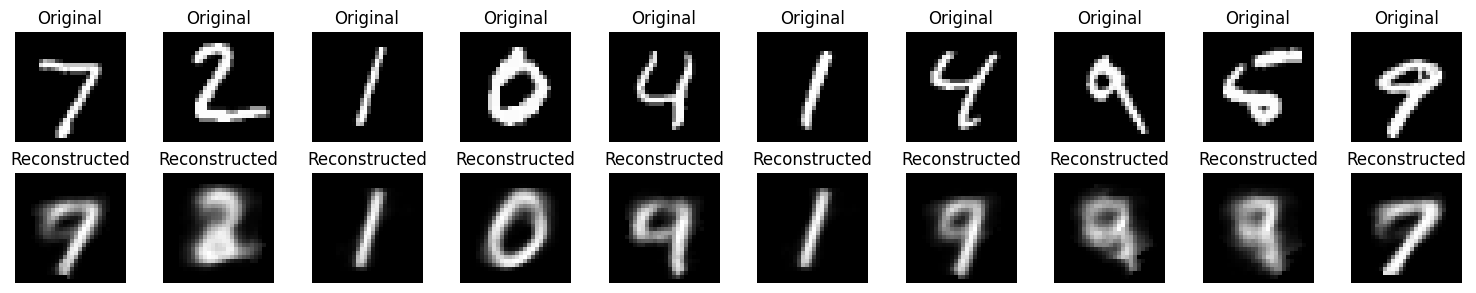

In [12]:
test_samples, _ = next(iter(test_data_loader))
test_samples = test_samples[:num_reconstructions].to(device).view(num_reconstructions, -1)

with torch.no_grad():
    _, reconstructions = model(test_samples)

reconstructions = reconstructions.cpu().view(num_reconstructions, 1, 28, 28)
test_samples = test_samples.cpu().view(num_reconstructions, 1, 28, 28)

fig, axes = plt.subplots(2, num_reconstructions, figsize=(15, 3))
for i in range(num_reconstructions):
    axes[0, i].imshow(test_samples[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[0, i].set_title("Original")
    axes[1, i].imshow(reconstructions[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')
    axes[1, i].set_title("Reconstructed")
plt.tight_layout()
plt.show()

Question 2) Implement VAE for synthesizing digits using MNIST training data.

Epoch: 1, Loss: 180.0617
Epoch: 2, Loss: 164.3247
Epoch: 3, Loss: 160.9010
Epoch: 4, Loss: 158.6613
Epoch: 5, Loss: 157.1333
Epoch: 6, Loss: 155.9161
Epoch: 7, Loss: 154.9566
Epoch: 8, Loss: 154.1050
Epoch: 9, Loss: 153.4058
Epoch: 10, Loss: 152.7696


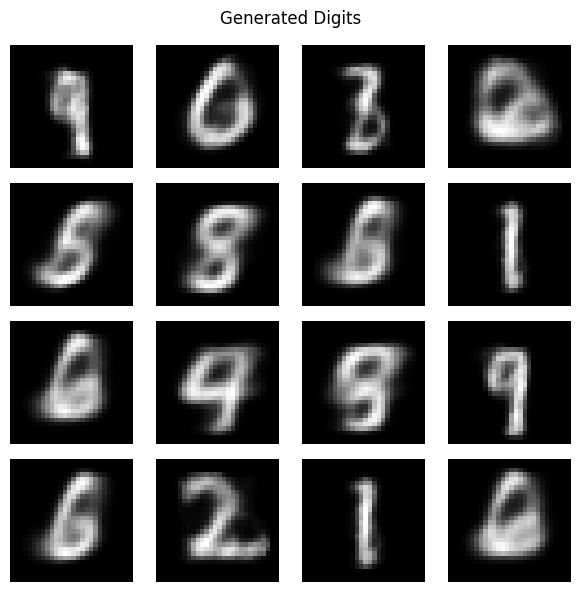

In [13]:
import torch.nn.functional as F
import matplotlib.pyplot as plt

# VAE Model
class VAE(nn.Module):
    def __init__(self, ld):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.mu = nn.Linear(400, ld)
        self.logvar = nn.Linear(400, ld)
        self.fc2 = nn.Linear(ld, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h1 = F.relu(self.fc1(x))
        return self.mu(h1), self.logvar(h1)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h2 = F.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h2))

    def forward(self, x):
        mu, logvar = self.encode(x.view(-1, 784))
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=lr)

def loss_fn(recon_x, x, mu, logvar):
    bce = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    kld = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return bce + kld

def train(epoch):
    model.train()
    train_loss = 0
    for data, _ in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        recon, mu, logvar = model(data)
        loss = loss_fn(recon, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f'Epoch: {epoch}, Loss: {train_loss / len(train_loader.dataset):.4f}')

def generate(num_samples):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, latent_dim).to(device)
        samples = model.decode(z).cpu().view(-1, 1, 28, 28)
        fig, axes = plt.subplots(int(num_samples**0.5), int(num_samples**0.5), figsize=(6, 6))
        for i, ax in enumerate(axes.flat):
            ax.imshow(samples[i].squeeze(), cmap='gray')
            ax.axis('off')
        plt.suptitle("Generated Digits")
        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    for epoch in range(1, epochs + 1):
        train(epoch)
    generate(16)